# Adjective Significance by Position: Building a Domain Dictionary

**Goal:** Let the data tell us which adjectives matter — and for which positions.

This notebook follows a 3-step methodology:

| Step | Action | Output |
|---|---|---|
| **A** | Group by position | Baseline scout-speak vocabulary per position |
| **B** | Split each position by outcome (Success / Bust) | Per-position frequency tables |
| **C** | Compute significance (Log-Likelihood G² + Frequency Ratio) | Domain dictionary: high-signal adjectives per position |

### Why adjectives only?
Nouns (player names, colleges, teams) are noise — they vary by cohort and carry no signal about *how* a player plays. Adjectives describe athletic traits and tendencies: the language scouts use to convey potential.

### Why position-specific?
> `"heavy"` is a positive for a Defensive Tackle but a red flag for a Cornerback.

A single global frequency table would drown out this positional signal. We need to measure "does this word predict success *for this position*?"

### Significance metrics
- **Log-Likelihood Ratio G²** (Dunning 1993) — robust to rare words; the standard in corpus linguistics. High G² = word appears much more in one group than chance would predict.
- **Frequency Ratio** (with Laplace smoothing) — simpler; easy to explain. Shown alongside G² to let you compare.

## 1. Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import spacy
import spacy.cli
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter, defaultdict
from time import time
from scipy.stats import chi2

print(f"spaCy version: {spacy.__version__}")

In [ ]:
# ── Position aggregation level ────────────────────────────────────────────────
# Choose one of:
#   "position"   → raw position  (CB, QB, OT, …)
#   "Pos_Group"  → position group (DB, OL, LB, …)
#   "Group"      → broad group   (SKILL D, BIG O, COMBO D, QB, SPECIAL, …)
POS_LEVEL = "position"

# Minimum players required to keep a group. Auto-scales with aggregation level.
MIN_PLAYERS = {"position": 50, "Pos_Group": 80, "Group": 100}.get(POS_LEVEL, 50)

# ── Feature type ──────────────────────────────────────────────────────────────
# Choose one of:
#   "adjectives"   → single adjective lemmas only (fast, no parser needed)
#   "noun_chunks"  → spaCy noun phrases, e.g. "quick feet", "elite burst"
#   "both"         → run both analyses back-to-back
FEATURE_TYPE = "both"

## 2. Load spaCy Model

We disable `parser` and `ner` — we only need the POS tagger and lemmatizer. This roughly halves inference time.

In [ ]:
import subprocess, sys

# Noun chunks require the dependency parser; adjective-only mode can skip it.
_disable = ["ner"] if FEATURE_TYPE in ("noun_chunks", "both") else ["parser", "ner"]

try:
    nlp = spacy.load("en_core_web_sm", disable=_disable)
    print(f"Loaded en_core_web_sm  (disabled: {_disable})")
except OSError:
    print("Model not found — downloading en_core_web_sm...")
    subprocess.run(
        [sys.executable, "-m", "spacy", "download", "en_core_web_sm"],
        check=True
    )
    nlp = spacy.load("en_core_web_sm", disable=_disable)
    print(f"Loaded en_core_web_sm  (disabled: {_disable})")

# Bump the max text length for long combined reports
nlp.max_length = 2_000_000

## 3. Load Data

In [ ]:
TARGET  = "made_it_contract"
POS_COL = POS_LEVEL
MIN_PLAYERS_PER_POSITION = MIN_PLAYERS

df = pd.read_csv("../data/processed/draft_enriched_with_contracts.csv")

df = df.dropna(subset=[TARGET]).copy()
df[TARGET] = df[TARGET].astype(int)

df['combined_text'] = (
    df['overview'].fillna('') + ' ' +
    df['strengths'].fillna('') + ' ' +
    df['weaknesses'].fillna('')
).str.strip()

df = df[df['combined_text'] != ''].copy()

# Filter groups with enough players
pos_counts = df[POS_COL].value_counts()
valid_positions = pos_counts[pos_counts >= MIN_PLAYERS_PER_POSITION].index
df = df[df[POS_COL].isin(valid_positions)].copy().reset_index(drop=True)

print(f"Aggregation level : {POS_COL}")
print(f"Rows: {len(df)}")
print(f"\nGroups (≥{MIN_PLAYERS_PER_POSITION} players):")
print(df[POS_COL].value_counts().to_string())
print(f"\nOverall positive rate: {df[TARGET].mean():.1%}")

## 4. Extract Adjectives per Player (spaCy POS Tagging)

We use `nlp.pipe` for batch processing — much faster than calling `nlp()` one document at a time.

In [ ]:
def extract_adjectives_batch(texts, batch_size=64):
    """Return a list of adjective-lemma lists, one per text."""
    results = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        adjs = [
            token.lemma_.lower()
            for token in doc
            if token.pos_ == "ADJ"
            and not token.is_stop
            and token.is_alpha
            and len(token.lemma_) > 1
        ]
        results.append(adjs)
    return results


def extract_noun_chunks_batch(texts, batch_size=64):
    """Return a list of noun-chunk string lists, one per text.
    Requires parser to be enabled (FEATURE_TYPE != 'adjectives').
    """
    results = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        chunks = [
            chunk.text.lower().strip()
            for chunk in doc.noun_chunks
            if chunk.text.replace(" ", "").isalpha()
            and len(chunk.text) > 2
            and not all(t.is_stop for t in chunk)   # drop all-stopword chunks ("him", "who")
            and not chunk.root.is_stop               # drop stop-headed chunks ("the player")
        ]
        results.append(chunks)
    return results


print(f"Extracting features via spaCy (FEATURE_TYPE='{FEATURE_TYPE}')...")
t0 = time()
texts = df['combined_text'].tolist()

if FEATURE_TYPE in ('adjectives', 'both'):
    df['adjectives'] = extract_adjectives_batch(texts)
    avg = df['adjectives'].apply(len).mean()
    print(f"  adjectives  — {avg:.1f} avg per report")

if FEATURE_TYPE in ('noun_chunks', 'both'):
    df['noun_chunks'] = extract_noun_chunks_batch(texts)
    avg = df['noun_chunks'].apply(len).mean()
    print(f"  noun_chunks — {avg:.1f} avg per report")

print(f"Done in {time()-t0:.1f}s")

## 5. Analysis Function

`run_analysis(df, tokens_col, label)` runs all three steps for any token column:

| Step | Action |
|---|---|
| **A** | Top tokens per position (overall frequency) |
| **B/C** | G² + Frequency Ratio per position × outcome |
| **Viz A** | Diverging bar chart (signed G²) |
| **Viz B** | Heatmap: positions × top tokens |
| **Viz C** | Freq Ratio vs G² scatter |
| **Dict** | Save domain dictionary CSV |

In [47]:
from matplotlib.patches import Patch

# ── Significance constants ────────────────────────────────────────────────────
G2_THRESHOLD = chi2.ppf(0.95, df=1)   # ≈ 3.84  (p < 0.05)
EPSILON      = 0.5                      # Laplace smoothing
MIN_COUNT    = 3                        # ignore very rare tokens


def llr_2x2(a, b, c, d):
    """Log-Likelihood Ratio G² for a 2×2 contingency table."""
    N = a + b + c + d
    total_pos     = a + b
    total_neg     = c + d
    total_success = a + c
    total_bust    = b + d

    def safe_term(o, e):
        return o * np.log(o / e) if o > 0 and e > 0 else 0.0

    E_a = total_pos * total_success / N
    E_b = total_pos * total_bust    / N
    E_c = total_neg * total_success / N
    E_d = total_neg * total_bust    / N

    return 2 * (safe_term(a, E_a) + safe_term(b, E_b) +
                safe_term(c, E_c) + safe_term(d, E_d))


def run_analysis(df, tokens_col, label, positions, valid_positions):
    """Run Steps A, B/C + all visualisations for a given token column.

    Parameters
    ----------
    tokens_col : str   column of token lists, e.g. 'adjectives' or 'noun_chunks'
    label      : str   used in plot titles and output filename
    """
    n_pos = len(positions)

    # ── Step A: top tokens per position ──────────────────────────────────────
    position_counters = {}
    for pos in sorted(valid_positions):
        all_toks = []
        for toks in df.loc[df[POS_COL] == pos, tokens_col]:
            all_toks.extend(toks)
        position_counters[pos] = Counter(all_toks)

    ncols = 3
    nrows = (n_pos + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
    axes = axes.flatten()
    for i, pos in enumerate(positions):
        top = position_counters[pos].most_common(15)
        if top:
            words, counts = zip(*top)
        else:
            words, counts = [], []
        ax = axes[i]
        ax.barh(words[::-1], counts[::-1], color='steelblue')
        n_players = df[POS_COL].value_counts()[pos]
        ax.set_title(f"{pos}  (n={n_players})", fontweight='bold')
        ax.set_xlabel('Count')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'[{label}] Step A: Most Common per Position (Overall)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Steps B/C: G² per position × outcome ─────────────────────────────────
    records = []
    for pos in positions:
        pos_df    = df[df[POS_COL] == pos]
        success   = pos_df[pos_df[TARGET] == 1]
        bust      = pos_df[pos_df[TARGET] == 0]
        N_success = len(success)
        N_bust    = len(bust)

        success_sets = success[tokens_col].apply(set)
        bust_sets    = bust[tokens_col].apply(set)

        vocab = set()
        for toks in pos_df[tokens_col]:
            vocab.update(toks)

        for word in vocab:
            a = sum(1 for s in success_sets if word in s)
            b = sum(1 for s in bust_sets    if word in s)
            if a + b < MIN_COUNT:
                continue
            c = N_success - a
            d = N_bust    - b

            freq_s     = (a + EPSILON) / (N_success + EPSILON)
            freq_b     = (b + EPSILON) / (N_bust    + EPSILON)
            freq_ratio = freq_s / freq_b
            log2_ratio = np.log2(freq_ratio)
            g2         = llr_2x2(a, b, c, d)
            signed_g2  = np.sign(log2_ratio) * g2

            records.append({
                'position':      pos,
                'token':         word,
                'count_success': a,
                'count_bust':    b,
                'N_success':     N_success,
                'N_bust':        N_bust,
                'freq_ratio':    freq_ratio,
                'log2_ratio':    log2_ratio,
                'G2':            g2,
                'signed_G2':     signed_g2,
                'significant':   g2 > G2_THRESHOLD,
            })

    sig_df = pd.DataFrame(records)
    print(f"[{label}] token×position pairs: {len(sig_df):,}  |  "
          f"significant (G²>{G2_THRESHOLD:.2f}): {sig_df['significant'].sum():,}")

    # ── Viz A: diverging bars ─────────────────────────────────────────────────
    TOP_N = 12
    ncols2 = 2
    nrows2 = (n_pos + ncols2 - 1) // ncols2
    fig, axes = plt.subplots(nrows2, ncols2, figsize=(18, nrows2 * 4.5))
    axes = axes.flatten()
    for i, pos in enumerate(positions):
        ax   = axes[i]
        data = sig_df[sig_df['position'] == pos].copy()
        combined = (
            pd.concat([data.nsmallest(TOP_N, 'signed_G2'),
                       data.nlargest(TOP_N, 'signed_G2')])
            .drop_duplicates('token')
            .sort_values('signed_G2')
        )
        colors = ['#d73027' if v < 0 else '#4575b4' for v in combined['signed_G2']]
        ax.barh(combined['token'], combined['signed_G2'], color=colors)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.axvline( G2_THRESHOLD, color='gray', linewidth=0.6, linestyle='--', alpha=0.7)
        ax.axvline(-G2_THRESHOLD, color='gray', linewidth=0.6, linestyle='--', alpha=0.7)
        n_players = df[POS_COL].value_counts()[pos]
        ax.set_title(f"{pos}  (n={n_players})", fontweight='bold')
        ax.set_xlabel('Signed G²  ← Bust | Success →')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    legend_elements = [
        Patch(facecolor='#4575b4', label='Success signal'),
        Patch(facecolor='#d73027', label='Bust / Red-flag signal'),
    ]
    fig.legend(handles=legend_elements, loc='lower right', fontsize=11)
    plt.suptitle(f'[{label}] Step B/C: Success vs Bust Signal (Signed G²)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Viz B: heatmap ────────────────────────────────────────────────────────
    TOP_GLOBAL = 35
    max_abs_g2 = sig_df.groupby('token')['signed_G2'].apply(lambda x: x.abs().max())
    top_tokens = max_abs_g2.nlargest(TOP_GLOBAL).index.tolist()

    heat_data = (
        sig_df[sig_df['token'].isin(top_tokens)]
        .pivot_table(index='position', columns='token', values='signed_G2', fill_value=0)
        .reindex(columns=top_tokens)
    )
    sig_mask = (
        sig_df[sig_df['token'].isin(top_tokens)]
        .pivot_table(index='position', columns='token', values='significant', fill_value=False)
        .reindex(columns=top_tokens)
        .astype(bool)   # pivot_table can return object dtype; force bool for .where()
    )
    masked = heat_data.where(sig_mask, other=0)
    vmax   = masked.abs().max().max()

    fig, ax = plt.subplots(figsize=(max(14, TOP_GLOBAL * 0.45), max(6, len(positions) * 0.7)))
    im = ax.imshow(masked.values, cmap=plt.cm.RdBu, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(top_tokens)))
    ax.set_xticklabels(top_tokens, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(masked.index)))
    ax.set_yticklabels(masked.index, fontsize=10)
    plt.colorbar(im, ax=ax, label='Signed G²  (Blue=Success, Red=Bust, White=n.s.)')
    ax.set_title(f'[{label}] Heatmap: Top {TOP_GLOBAL} tokens by Max |G²|\n'
                 '(only statistically significant cells coloured)', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Viz C: freq ratio vs G² scatter ──────────────────────────────────────
    LABEL_TOP_N = 10
    ncols3 = 3
    nrows3 = (n_pos + ncols3 - 1) // ncols3
    fig, axes = plt.subplots(nrows3, ncols3, figsize=(18, nrows3 * 4))
    axes = axes.flatten()
    for i, pos in enumerate(positions):
        ax   = axes[i]
        data = sig_df[sig_df['position'] == pos].copy()
        colors = ['#4575b4' if v >= 0 else '#d73027' for v in data['log2_ratio']]
        ax.scatter(data['log2_ratio'], data['G2'], c=colors, alpha=0.5, s=20)
        ax.axhline(G2_THRESHOLD, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.axvline(0, color='black', linewidth=0.6)
        for _, row in data.nlargest(LABEL_TOP_N, 'G2').iterrows():
            ax.annotate(row['token'], xy=(row['log2_ratio'], row['G2']),
                        fontsize=7, ha='center', va='bottom',
                        xytext=(0, 3), textcoords='offset points')
        n_players = df[POS_COL].value_counts()[pos]
        ax.set_title(f"{pos}  (n={n_players})", fontweight='bold')
        ax.set_xlabel('log₂(Freq Ratio)  ← Bust | Success →')
        ax.set_ylabel('G²')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'[{label}] Freq Ratio vs G²: Reliable Signal in Top-Right / Bottom-Right',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Domain dictionary ─────────────────────────────────────────────────────
    domain_dict = (
        sig_df[sig_df['significant']]
        .assign(
            signal            = lambda d: np.where(d['log2_ratio'] > 0, 'Success', 'Bust'),
            freq_ratio_rounded= lambda d: d['freq_ratio'].round(3),
            G2_rounded        = lambda d: d['G2'].round(2),
        )
        [['position', 'token', 'signal', 'count_success', 'count_bust',
          'freq_ratio_rounded', 'G2_rounded']]
        .rename(columns={'freq_ratio_rounded': 'freq_ratio', 'G2_rounded': 'G2'})
        .sort_values(['position', 'signal', 'G2'], ascending=[True, True, False])
        .reset_index(drop=True)
    )
    out_path = f"../data/processed/domain_{label}_dict.csv"
    domain_dict.to_csv(out_path, index=False)
    print(f"[{label}] Domain dict: {len(domain_dict)} entries → {out_path}")
    print(domain_dict.groupby(['position', 'signal']).size().unstack(fill_value=0).to_string())
    return sig_df, domain_dict


print("run_analysis() defined.")

run_analysis() defined.


## 6. Run Analysis


  NOUN_CHUNKS



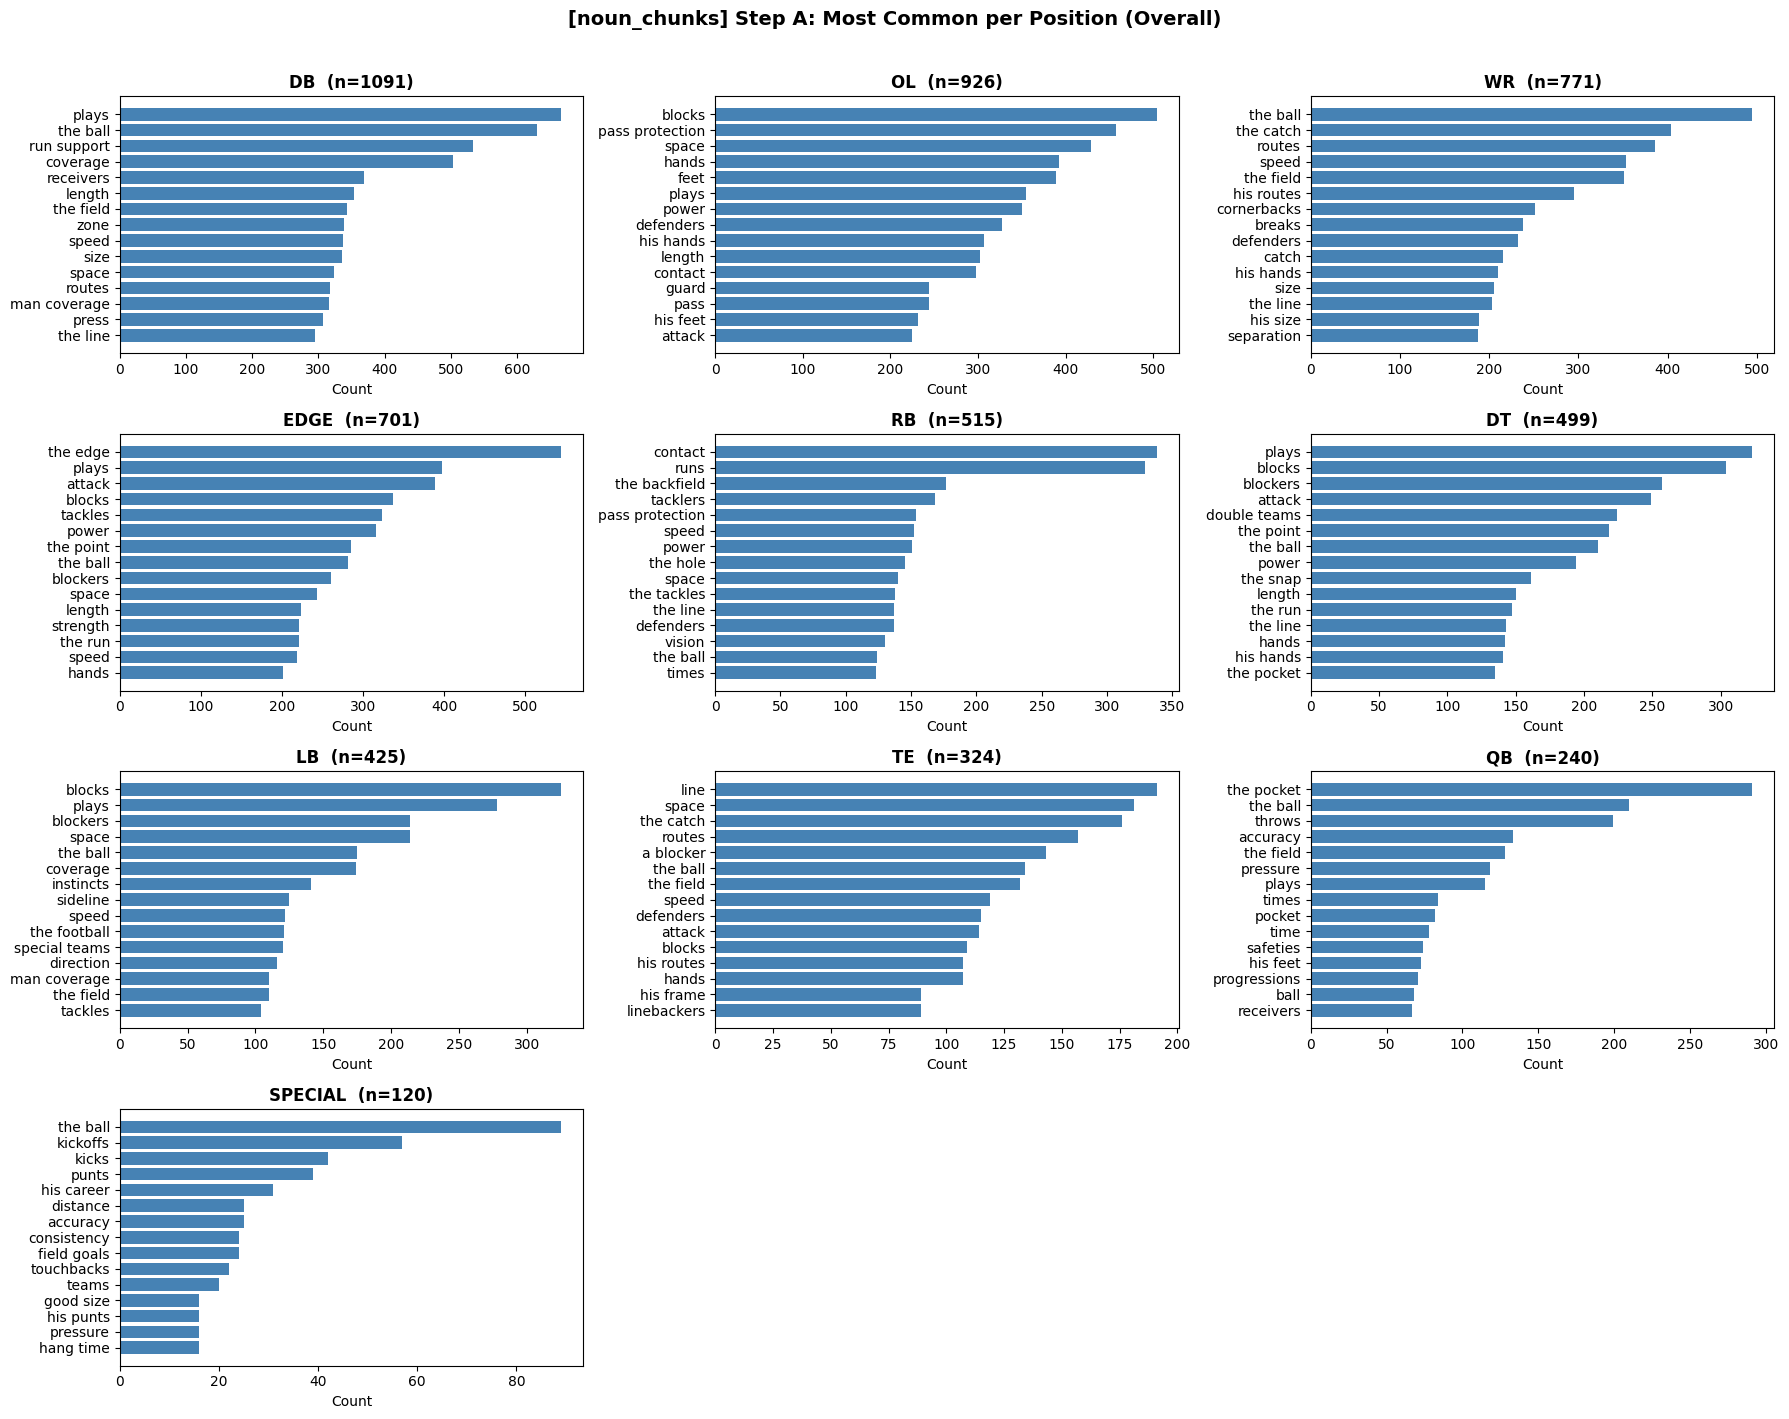

[noun_chunks] token×position pairs: 14,655  |  significant (G²>3.84): 1,055


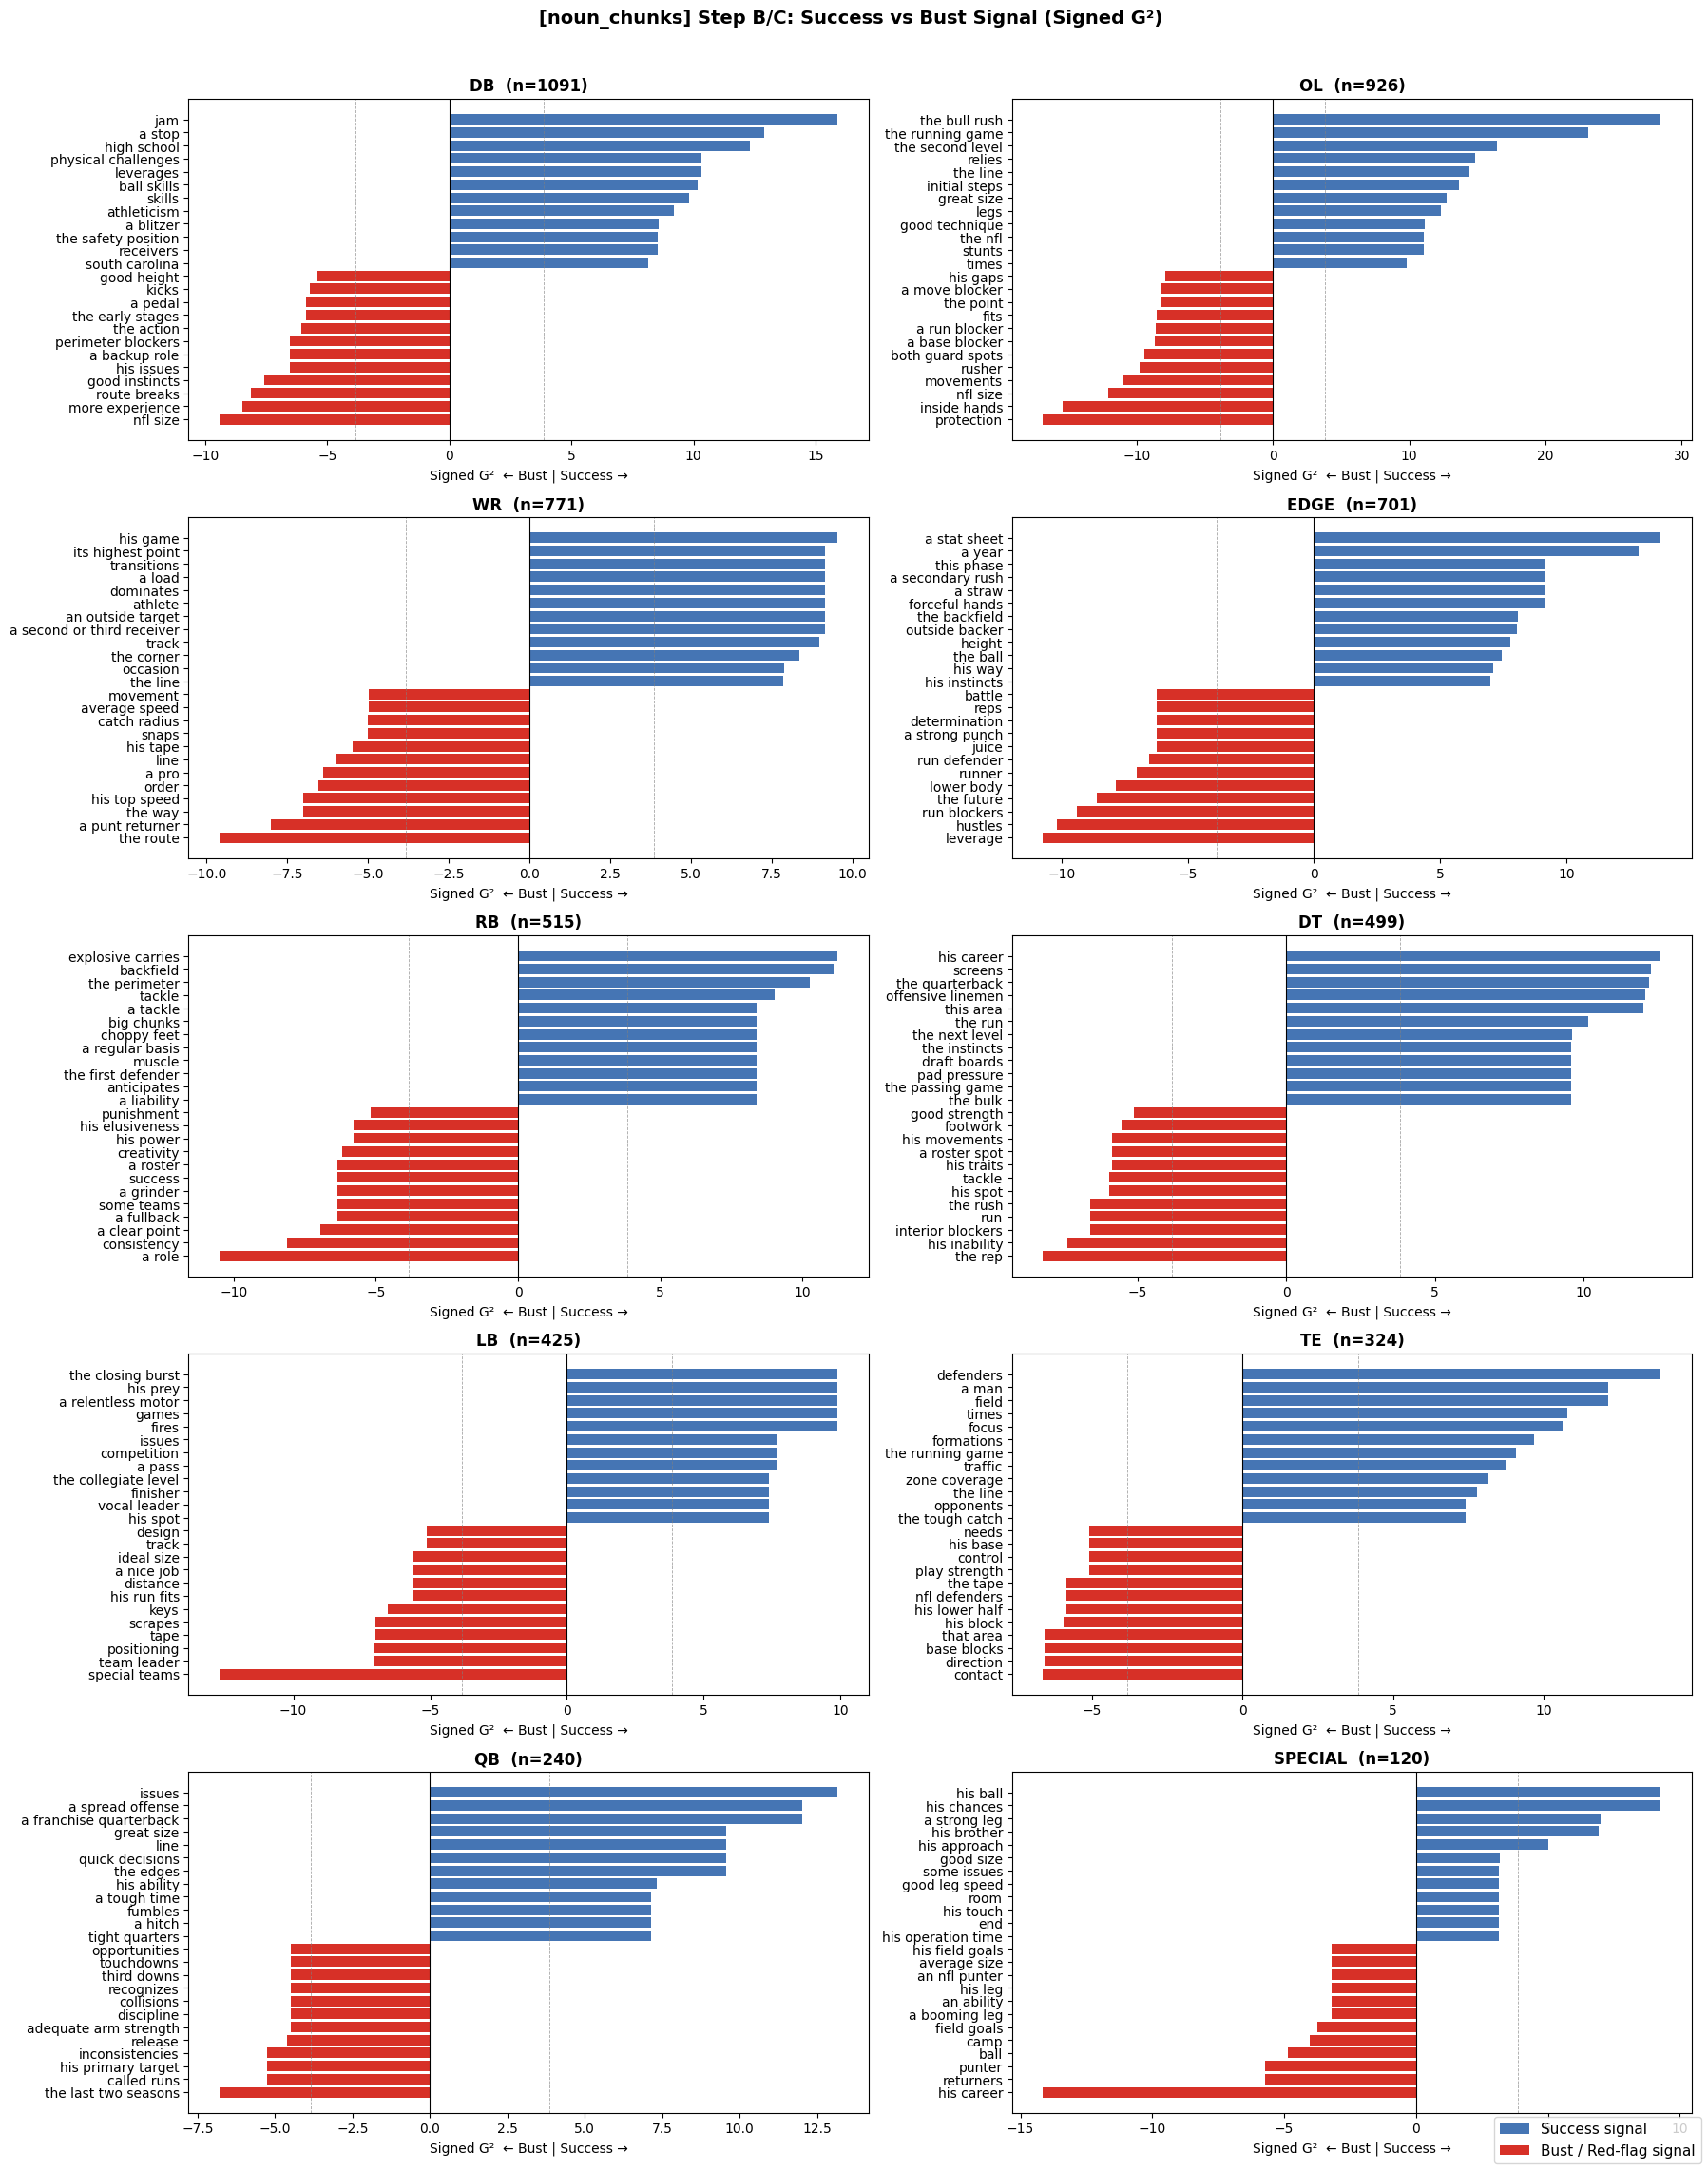

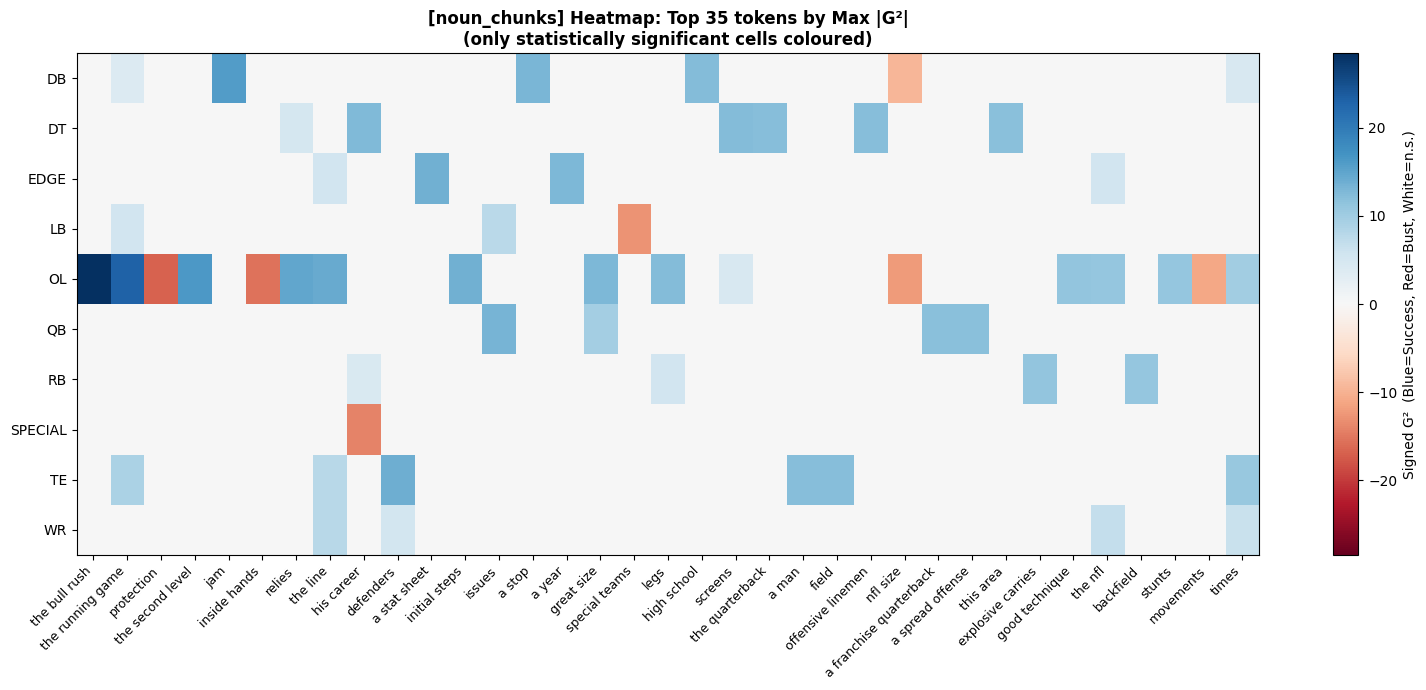

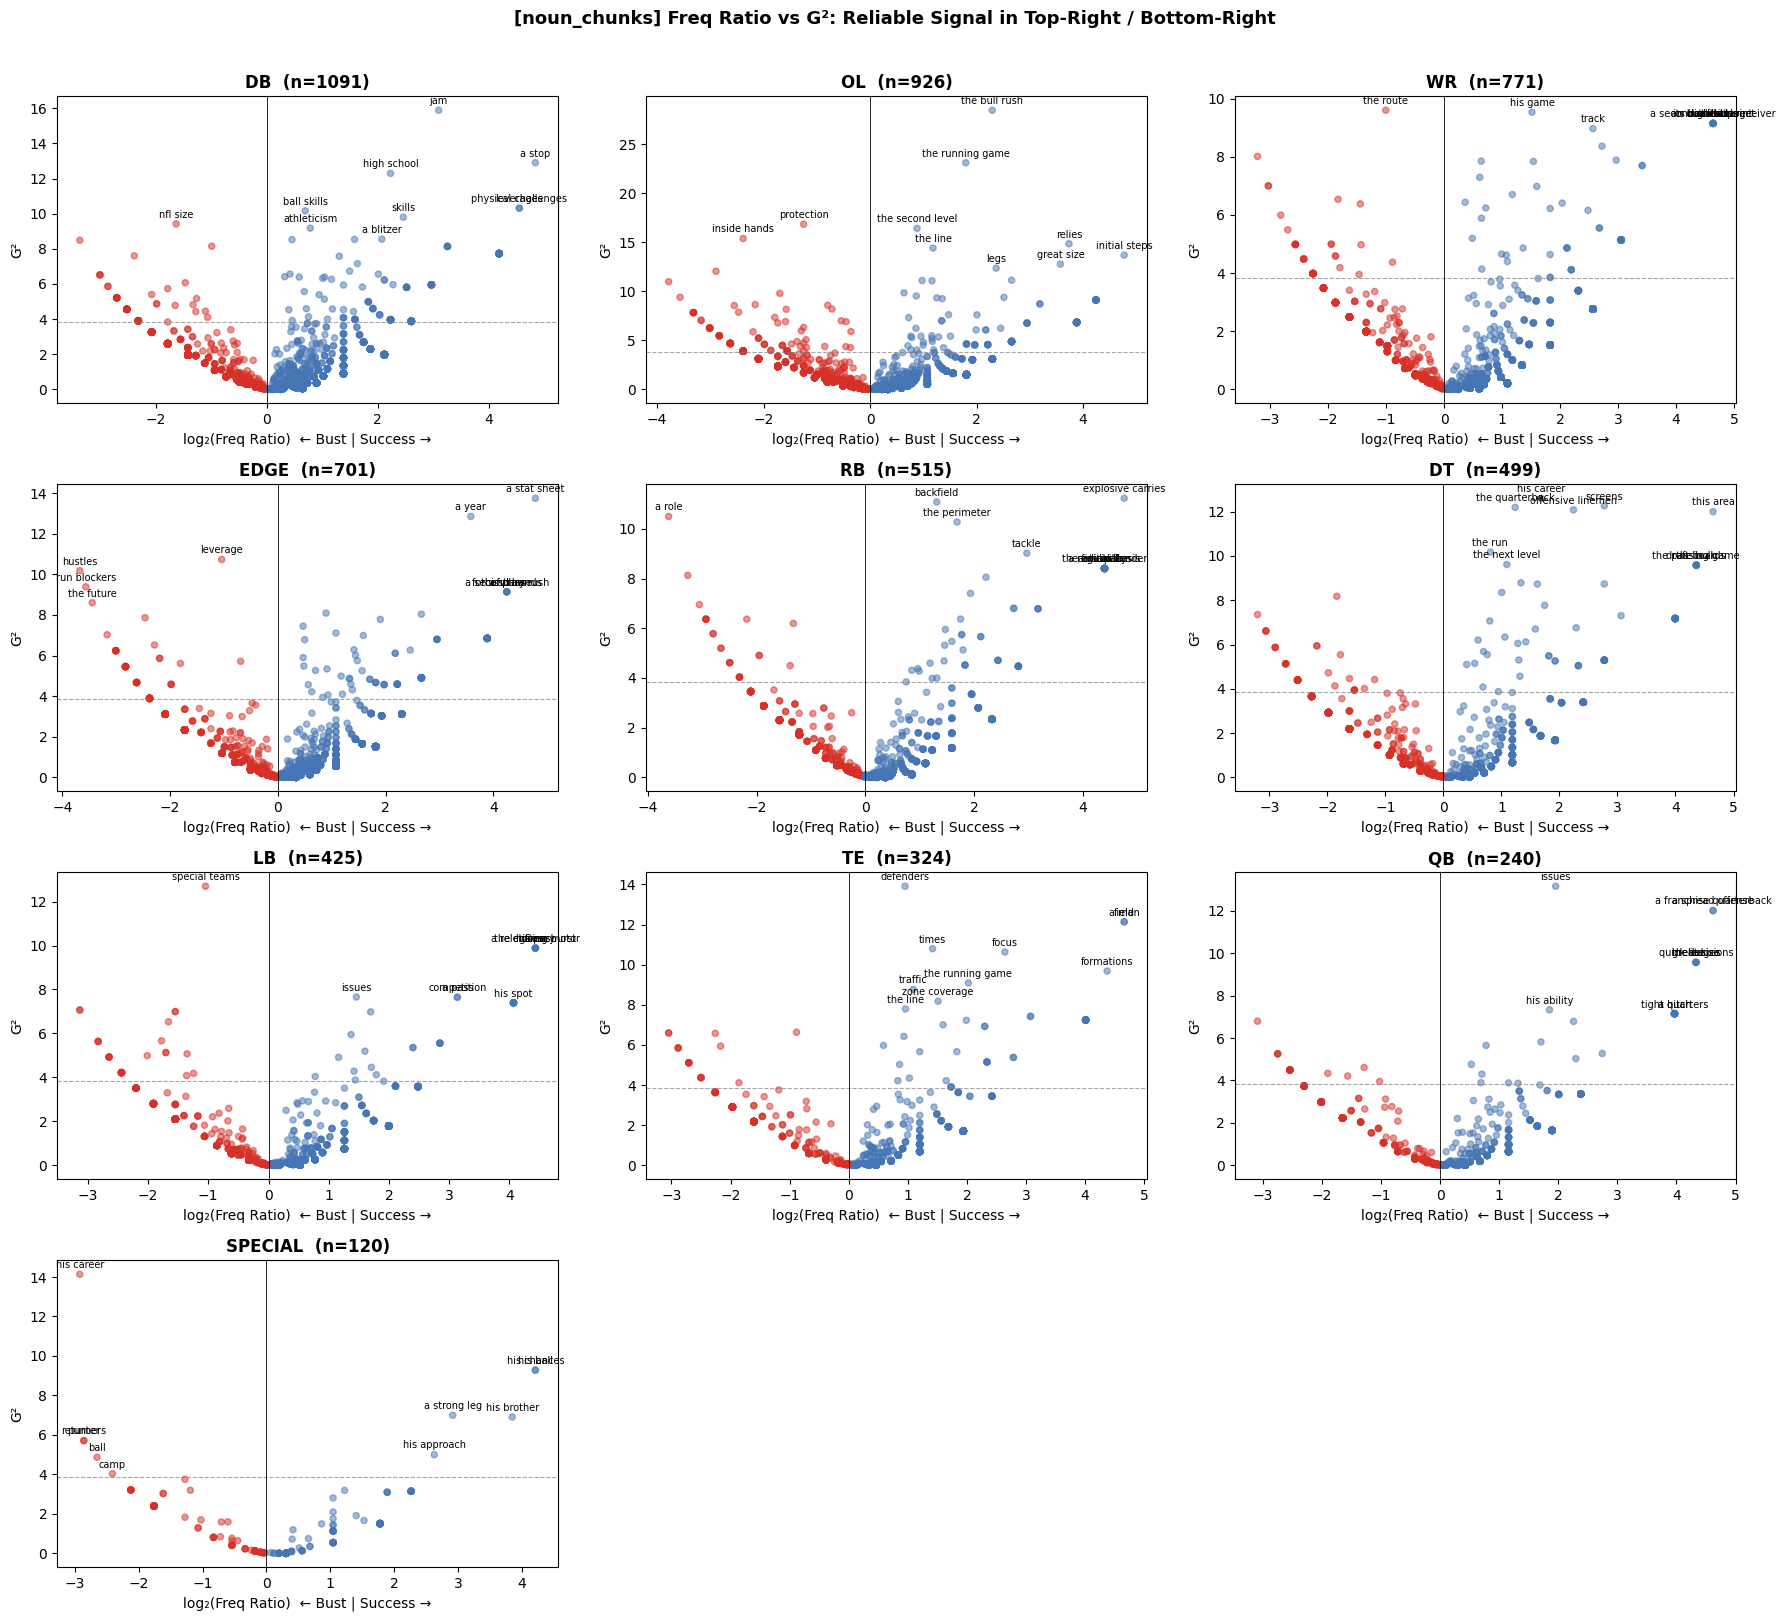

[noun_chunks] Domain dict: 1055 entries → ../data/processed/domain_noun_chunks_dict.csv
signal    Bust  Success
position               
DB          69      160
DT          38       64
EDGE        56       82
LB          30       32
OL         114      115
QB          16       30
RB          23       56
SPECIAL      5        5
TE          18       46
WR          39       57


In [48]:
positions = sorted(valid_positions, key=lambda p: -df[POS_COL].value_counts()[p])

feature_runs = []
if FEATURE_TYPE in ('adjectives', 'both'):
    feature_runs.append(('adjectives', 'adjectives'))
if FEATURE_TYPE in ('noun_chunks', 'both'):
    feature_runs.append(('noun_chunks', 'noun_chunks'))

results = {}
for tokens_col, label in feature_runs:
    print(f"\n{'='*60}")
    print(f"  {label.upper()}")
    print(f"{'='*60}\n")
    sig_df, domain_dict = run_analysis(df, tokens_col, label, positions, valid_positions)
    results[label] = {'sig_df': sig_df, 'domain_dict': domain_dict}